In [1]:
!pip install yfinance

In [2]:
from datetime import date, timedelta

days = 100

today = date.today()
# yfinance `end` is exclusive, so add 1 day to include today
end_date = (today + timedelta(days=1)).strftime("%Y-%m-%d")

start_date = today - timedelta(days=days)
start_date = start_date.strftime("%Y-%m-%d")


In [3]:
import yfinance as yf
import pandas as pd

data = yf.download('BTC-USD',
                   start=start_date,
                   end=end_date,
                   progress=False)

# Newer yfinance versions return MultiIndex columns when downloading a
# single ticker. Flatten them so `data['Adj Close']` works as a Series.
if isinstance(data.columns, pd.MultiIndex):
    # If the first level is a constant (e.g. 'Price'), drop it and use the
    # second level (field names: Close, High, Low, Open, Volume).
    if data.columns.get_level_values(0).nunique() == 1:
        data.columns = data.columns.get_level_values(1)
    else:
        data.columns = data.columns.get_level_values(0)

# Newer yfinance defaults to auto_adjust=True, which drops 'Adj Close'.
# Restore it from 'Close' so downstream cells keep working unchanged.
if 'Adj Close' not in data.columns and 'Close' in data.columns:
    data['Adj Close'] = data['Close']

data


Price,Close,High,Low,Open,Volume,Adj Close
Date,,,,,,
2026-04-18,75726.210938,77416.703125,75504.945312,77136.046875,26014416776,75726.210938
2026-04-19,73856.351562,76243.093750,73802.382812,75723.695312,30931515195,73856.351562
2026-04-20,75872.523438,76575.359375,73775.570312,73854.250000,39674447916,75872.523438
2026-04-21,76352.773438,76881.476562,74852.671875,75872.828125,36453522626,76352.773438
2026-04-22,78203.101562,79468.000000,76159.578125,76354.218750,48336654537,78203.101562
...,...,...,...,...,...,...
2026-07-23,65044.812500,66282.382812,64610.609375,66100.132812,24364433538,65044.812500
2026-07-24,64098.496094,65760.484375,63686.035156,65044.957031,25917559237,64098.496094
2026-07-25,64311.812500,64386.062500,63753.027344,64098.492188,13817493398,64311.812500


In [4]:
data["Date"] = data.index
data.reset_index(drop=True, inplace=True)
data

Price,Close,High,Low,Open,Volume,Adj Close,Date
0,75726.210938,77416.703125,75504.945312,77136.046875,26014416776,75726.210938,2026-04-18
1,73856.351562,76243.093750,73802.382812,75723.695312,30931515195,73856.351562,2026-04-19
2,75872.523438,76575.359375,73775.570312,73854.250000,39674447916,75872.523438,2026-04-20
3,76352.773438,76881.476562,74852.671875,75872.828125,36453522626,76352.773438,2026-04-21
4,78203.101562,79468.000000,76159.578125,76354.218750,48336654537,78203.101562,2026-04-22
...,...,...,...,...,...,...,...
96,65044.812500,66282.382812,64610.609375,66100.132812,24364433538,65044.812500,2026-07-23
97,64098.496094,65760.484375,63686.035156,65044.957031,25917559237,64098.496094,2026-07-24
98,64311.812500,64386.062500,63753.027344,64098.492188,13817493398,64311.812500,2026-07-25
99,65340.300781,65503.769531,64233.453125,64311.785156,14301494281,65340.300781,2026-07-26


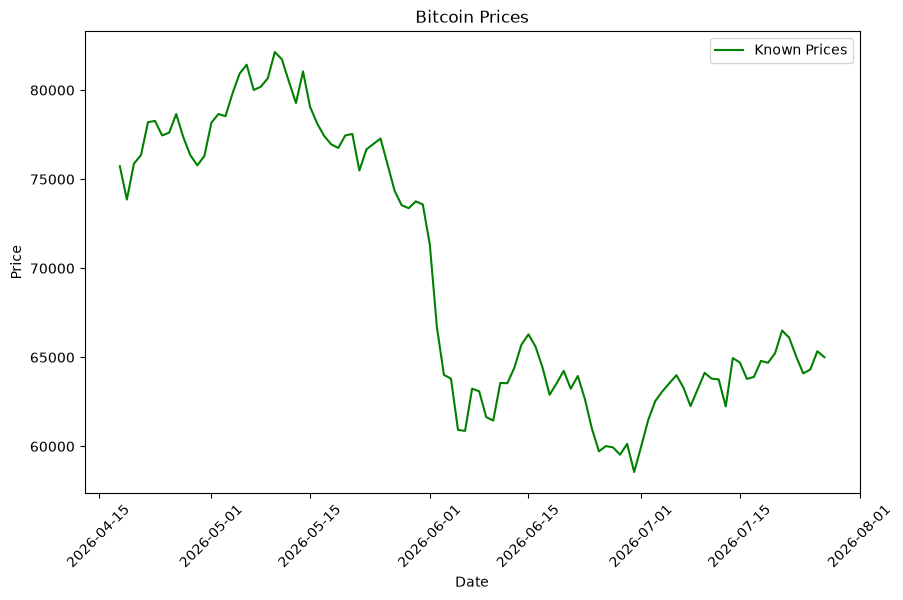

In [5]:
import matplotlib.pyplot as plt

dates = data['Date'] 

prices = data['Adj Close'] 

plt.figure(figsize=(10, 6))

plt.plot(dates, prices, color='green', label='Known Prices')
 
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Bitcoin Prices')

plt.xticks(rotation=45)

plt.legend()

plt.show()

In [6]:
import numpy as np

def create_dataset(serie, window_size=20):
    dataX, dataY = [], []
    for i in range(len(serie)-window_size-1):
        a = serie[i:(i+window_size), 0]  
        dataX.append(a)
        dataY.append([serie[i + window_size, 0]])
    return np.array(dataX), np.array(dataY)

In [7]:
from sklearn.preprocessing import MinMaxScaler

window_size=20

closedf=data[['Adj Close']]
scaler=MinMaxScaler(feature_range=(0,1))
closedf=scaler.fit_transform(closedf)
  
X, y = create_dataset(closedf, window_size)

In [8]:
X

array([[0.72804497, 0.64874667, 0.73424989, ..., 0.94860596, 0.96983052,
        0.90971454],
       [0.64874667, 0.73424989, 0.75461667, ..., 0.96983052, 0.90971454,
        0.91721127],
       [0.73424989, 0.75461667, 0.83308667, ..., 0.90971454, 0.91721127,
        0.93746573],
       ...,
       [0.19208786, 0.21157797, 0.23054029, ..., 0.33699075, 0.31984372,
        0.27506081],
       [0.21157797, 0.23054029, 0.20095509, ..., 0.31984372, 0.27506081,
        0.23492876],
       [0.23054029, 0.20095509, 0.15685767, ..., 0.27506081, 0.23492876,
        0.24397523]], shape=(80, 20))

In [9]:
y

array([[0.91721127],
       [0.93746573],
       [1.        ],
       [0.9825856 ],
       [0.9295406 ],
       [0.87863427],
       [0.95387292],
       [0.86966748],
       [0.83004749],
       [0.80027294],
       [0.78012119],
       [0.77150096],
       [0.80147827],
       [0.80493028],
       [0.71795303],
       [0.76821263],
       [0.78126424],
       [0.79393615],
       [0.73226563],
       [0.66945703],
       [0.63518451],
       [0.62822815],
       [0.64444153],
       [0.63701371],
       [0.54117371],
       [0.3454102 ],
       [0.23136096],
       [0.22233669],
       [0.10024604],
       [0.09790279],
       [0.19850069],
       [0.19218477],
       [0.13082751],
       [0.12257935],
       [0.21213657],
       [0.21137935],
       [0.24861948],
       [0.30328744],
       [0.32784638],
       [0.29863275],
       [0.24849739],
       [0.18395252],
       [0.21127912],
       [0.24091601],
       [0.1984167 ],
       [0.22872053],
       [0.17426412],
       [0.103

In [10]:
from sklearn.model_selection import train_test_split

# shuffle=False is mandatory for time-series: otherwise the model trains
# on future observations and tests on past ones (data leakage).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0, shuffle=False
)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,random_state = 0)

In [12]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.layers import LSTM

model = Sequential()

model.add(Input(shape=(window_size, 1)))

# Use default `tanh` activation for LSTM. `relu` causes unstable training
# because the recurrent path can blow up the cell state.
model.add(LSTM(units=32, dropout=0.1))

# Linear (default) output for regression. `relu` would clip negative
# residuals and bias the predictions.
model.add(Dense(1))

model.compile(loss="mean_squared_error", optimizer="adam", metrics=['mse'])


In [13]:
# LSTM expects input shape (samples, timesteps, features).
# create_dataset returns 2D (samples, window_size); add the feature dim.
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=10, batch_size=8)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.1797 - mse: 0.1797 - val_loss: 0.0756 - val_mse: 0.0756
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0624 - mse: 0.0624 - val_loss: 0.0285 - val_mse: 0.0285
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0249 - mse: 0.0249 - val_loss: 0.0334 - val_mse: 0.0334
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0497 - mse: 0.0497 - val_loss: 0.0288 - val_mse: 0.0288
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0244 - mse: 0.0244 - val_loss: 0.0247 - val_mse: 0.0247
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0462 - mse: 0.0462 - val_loss: 0.0243 - val_mse: 0.0243
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0338 - mse: 0.0338 - val_loss: 0.0236 - val_mse: 0.0236
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0289 - mse: 0.0289 - val_loss: 0.0231 - val_mse: 0.0231
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0216 - mse: 0.0216 - 

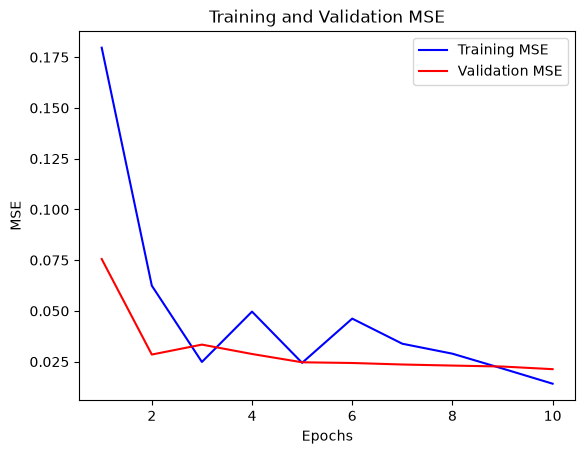

In [14]:
import matplotlib.pyplot as plt

train_mse = history.history['mse']
val_mse = history.history['val_mse']

epochs = range(1, len(train_mse) + 1)

plt.plot(epochs, train_mse, 'b', label='Training MSE')
plt.plot(epochs, val_mse, 'r', label='Validation MSE')
plt.title('Training and Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [15]:
pred_steps = 10
predicted_prices = []

# Seed the sliding window with the last known window. Reshape to
# (1, window_size, 1) to match the LSTM input shape.
X_pred = X[-1].reshape(1, window_size, 1)

for _ in range(pred_steps):
    prediction = model.predict(X_pred, verbose=0)   # shape (1, 1)
    predicted_prices.append(prediction[0, 0])       # store scalar

    # Slide the window: drop oldest timestep, append new prediction.
    new_step = prediction.reshape(1, 1, 1)          # shape (1, 1, 1)
    X_pred = np.concatenate([X_pred[:, 1:, :], new_step], axis=1)

# Build a (pred_steps, 1) float array so MinMaxScaler.inverse_transform
# works (it rejects object dtype and 1D inputs).
predicted_prices = np.array(predicted_prices, dtype=float).reshape(-1, 1)
predicted_prices = scaler.inverse_transform(predicted_prices)
print(predicted_prices)


[[65259.31706214]
 [65315.60590208]
 [65365.03809947]
 [65412.48645941]
 [65456.6038277 ]
 [65497.38247417]
 [65535.53497806]
 [65570.91376378]
 [65604.34525459]
 [65633.64252094]]


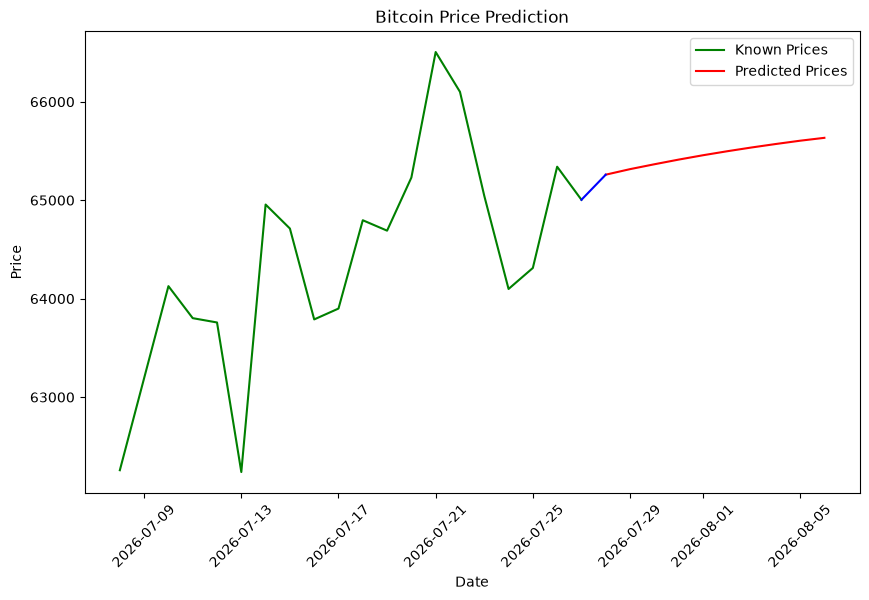

In [16]:
import matplotlib.pyplot as plt
previous_days = 20

dates_known = data["Date"].iloc[-previous_days:].values
known_prices = data["Adj Close"].iloc[-previous_days:].values

dates_pred = pd.date_range(start=today + timedelta(days=1),
                           periods=pred_steps).values

# Flatten to 1D so x and y have matching shapes in plt.plot.
predicted_flat = predicted_prices.flatten()

plt.figure(figsize=(10, 6))

plt.plot(dates_known, known_prices, color='green', label='Known Prices')
plt.plot(dates_pred, predicted_flat, color='red', label='Predicted Prices')

# Bridge the last known point and the first predicted point.
plt.plot([dates_known[-1], dates_pred[0]],
         [known_prices[-1], predicted_flat[0]],
         color='blue')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Bitcoin Price Prediction')

plt.xticks(rotation=45)
plt.legend()
plt.show()
